# M2 Deep Learning Coursework

Harvey Bermingham

In [1]:
import os
import random

#initialising a global seed (reproducibility; instructions CPU-only)
GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED) #setting Python's initialisation seed
os.environ['CUDA_VISIBLE_DEVICES'] = "-1" #avoiding use of any NVIDIA GPUs

#importing general packages
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import optuna

def set_seed(seed: int) -> None:
    """Reset Python, NumPy, and PyTorch RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(GLOBAL_SEED)
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


/Users/harvey/Documents/Cambridge/M2/Coursework/hb747/m2_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Preprocessing and Data Exploration

Before any modelling, the three datasets are loaded and inspected for missing values, duplicates, class balance, and feature scale. The final pipeline keeps the raw `x1, x2` coordinates, so the checks in this section describe the same inputs that are later passed to the flow.

In [2]:
# Load data
DATA_DIR = Path("data")
train_df = pd.read_csv(DATA_DIR / "moons_train.csv")
val_df = pd.read_csv(DATA_DIR / "moons_val.csv")
test_df = pd.read_csv(DATA_DIR / "moons_test.csv")


Exploring the layout of the datasets and defining their structure.

In [3]:
# Structure: shape, columns, dtypes
expected = {"train": 800, "val": 100, "test": 100}
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:<5s}  shape={str(df.shape):<10s}  columns={list(df.columns)}")
print("\ndtypes (all datasets identical):\n", train_df.dtypes)

train  shape=(800, 3)    columns=['x1', 'x2', 'class']
val    shape=(100, 3)    columns=['x1', 'x2', 'class']
test   shape=(100, 3)    columns=['x1', 'x2', 'class']

dtypes (all datasets identical):
 x1       float64
x2       float64
class      int64
dtype: object


The shape of each of the classes, column names and the dtypes appear as expected from the coursework outline.

**Missing values and duplicates**

In [4]:
# Missing values and duplicates
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    nan_x1 = df["x1"].isna().sum()
    nan_x2 = df["x2"].isna().sum()
    dup = df.duplicated(subset=["x1", "x2"]).sum()
    print(f"{name:<5s}  NaNs x1={nan_x1}  x2={nan_x2}  duplicates={dup}")

train  NaNs x1=0  x2=0  duplicates=0
val    NaNs x1=0  x2=0  duplicates=0
test   NaNs x1=0  x2=0  duplicates=0


No missing values or duplicates have been found in any of the provided datasets.

**Tensors and data as input**

In [5]:
# Raw feature tensors used as model inputs
x_train_raw = torch.from_numpy(train_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_val_raw = torch.from_numpy(val_df[["x1", "x2"]].to_numpy(dtype=np.float32))
x_test_raw = torch.from_numpy(test_df[["x1", "x2"]].to_numpy(dtype=np.float32))

# Keep train statistics for reporting and quick preprocessing comparisons
feature_mean = x_train_raw.mean(dim=0, keepdim=True)
feature_std = x_train_raw.std(dim=0, keepdim=True).clamp_min(1e-8)

# Final modelling choice: keep the original coordinates
x_train = x_train_raw.clone()
x_val = x_val_raw.clone()
x_test = x_test_raw.clone()
class_train = train_df["class"].values
class_val = val_df["class"].values
class_test = test_df["class"].values

print()
for name, t in [("x_train_raw", x_train_raw), ("x_val_raw", x_val_raw), ("x_test_raw", x_test_raw)]:
    mu = t.mean(dim=0)
    sd = t.std(dim=0).clamp_min(1e-8)
    print(f"{name:<11s} shape={str(tuple(t.shape)):<10s} dtype={str(t.dtype):<14s} min={t.min().item():>8.4f} max={t.max().item():>8.4f}")
    print(f"{'':<11s} mean=[{mu[0].item():>8.4f}, {mu[1].item():>8.4f}] std=[{sd[0].item():>8.4f}, {sd[1].item():>8.4f}]")

print()
for name, t in [("x_train_input", x_train), ("x_val_input", x_val), ("x_test_input", x_test)]:
    print(f"{name:<12s} shape={str(tuple(t.shape)):<10s} dtype={str(t.dtype):<14s} min={t.min().item():>8.4f} max={t.max().item():>8.4f}")


x_train_raw shape=(800, 2)   dtype=torch.float32  min= -1.1268 max=  2.0669
            mean=[  0.5210,   0.2313] std=[  0.8748,   0.4910]
x_val_raw   shape=(100, 2)   dtype=torch.float32  min= -1.0031 max=  2.0290
            mean=[  0.4606,   0.3343] std=[  0.7998,   0.5437]
x_test_raw  shape=(100, 2)   dtype=torch.float32  min= -1.0391 max=  2.0557
            mean=[  0.3662,   0.3227] std=[  0.8638,   0.5010]

x_train_input shape=(800, 2)   dtype=torch.float32  min= -1.1268 max=  2.0669
x_val_input  shape=(100, 2)   dtype=torch.float32  min= -1.0031 max=  2.0290
x_test_input shape=(100, 2)   dtype=torch.float32  min= -1.0391 max=  2.0557


All three datasets contain the expected sample counts (800 / 100 / 100) with columns `x1`, `x2`, and `class`. No missing values or duplicates appear in any split. In the training set, `x1` ranges roughly from -1.13 to 2.07 and `x2` from -0.61 to 1.20, with means `[0.52, 0.23]`; the coordinate distributions are already close to standard normal, so the final model uses them directly rather than applying an extra preprocessing transform.

**Class Distributions**

The following figures examine class structure, spatial layout of the raw features, and consistency across the train, validation, and test splits.

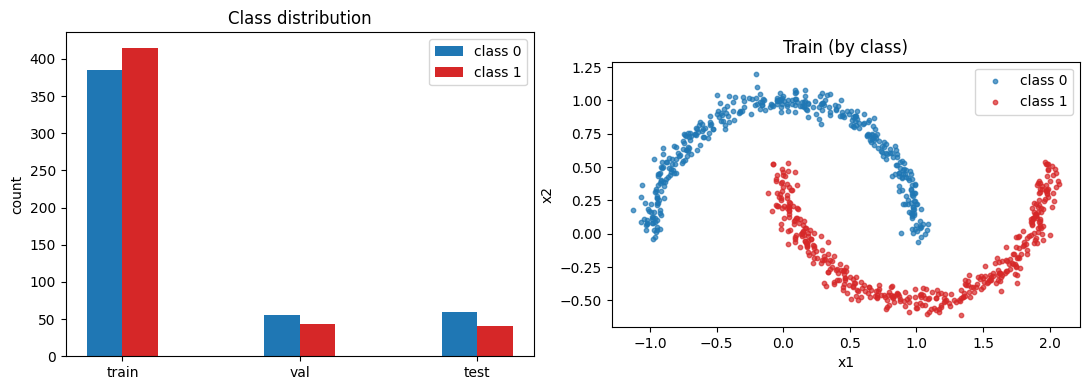

In [6]:
# Figure 1: Class distribution + Train (by class) scatter
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
splits = [("train", train_df), ("val", val_df), ("test", test_df)]
cnt = np.array([[(df["class"] == 0).sum(), (df["class"] == 1).sum()] for _, df in splits])
x, w = np.arange(3), 0.2
axes[0].bar(x - w/2, cnt[:, 0], w, label="class 0", color="#1f77b4")
axes[0].bar(x + w/2, cnt[:, 1], w, label="class 1", color="#d62728")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["train", "val", "test"])
axes[0].set_ylabel("count")
axes[0].set_title("Class distribution")
axes[0].legend()
X = x_train.numpy()
axes[1].scatter(X[class_train == 0, 0], X[class_train == 0, 1], c="#1f77b4", label="class 0", alpha=0.7, s=10)
axes[1].scatter(X[class_train == 1, 0], X[class_train == 1, 1], c="#d62728", label="class 1", alpha=0.7, s=10)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Train (by class)")
axes[1].legend()
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

The class distribution bar chart on the left shows small class imbalances across each of the datasets, none of which are considerable or should have an effect on training. The training dataset has around 400 samples per class whereas validation and test splits sit around 50 samples per class. The scatter plot shows the two classes in the training dataset create two disctinct overlapping moons which are non-linearly separable. 

**General Data Distribution and Density**

Below, we plot the distribution of the datasets.

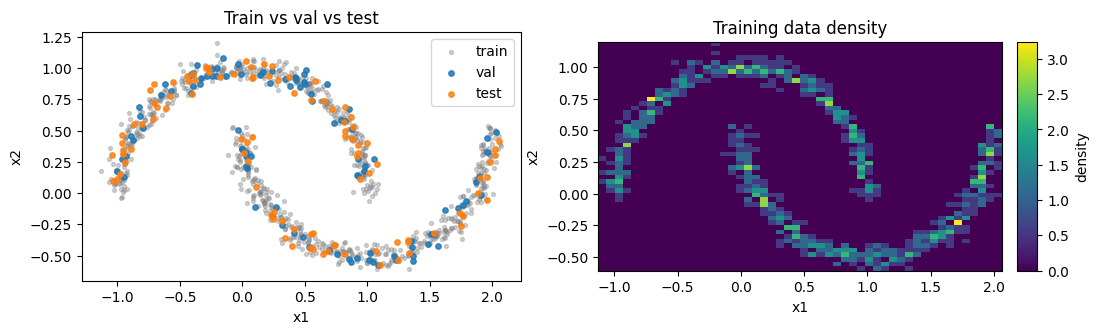

In [7]:
# Figure 2: Train vs val vs test + Training density
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(x_train[:, 0], x_train[:, 1], c="gray", alpha=0.35, s=8, label="train")
axes[0].scatter(x_val[:, 0], x_val[:, 1], alpha=0.85, s=15, label="val")
axes[0].scatter(x_test[:, 0], x_test[:, 1], alpha=0.85, s=15, label="test")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Train vs val vs test")
axes[0].legend()
axes[0].set_aspect("equal")
xt, yt = x_train[:, 0].numpy(), x_train[:, 1].numpy()
H_2d, xe, ye = np.histogram2d(xt, yt, bins=50)
H_2d = H_2d / (H_2d.sum() * (xe[1] - xe[0]) * (ye[1] - ye[0]))
pc = axes[1].pcolormesh(xe, ye, H_2d.T, shading="auto", cmap="viridis")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Training data density")
axes[1].set_aspect("equal")
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
fig.colorbar(pc, cax=cax, label="density")
plt.tight_layout()
plt.show()

The overlay on the left plot shows train, validation, and test points occupying the same region of feature space with no visible distribution shift between the classes, suggesting a model trained on training should be effective at predicting on validation and test. The density plot on the right shows nearly all of the probability mass is concentrated well within the outlines of the two moons. Peak density reaches approximately 3.0, while the density in the area outside of the moons sits close to zero. This regularity in the data should help the main train well as normalising flows are designed to be able to learn to predict between non linearly separable classes.

## 1. A Mini Normalising Flow

### 1) (a) 

A single affine coupling layer is implemented below. It keeps one component of the 2D input fixed and transforms the other via scale and shift parameters that will be produced by training a small network later in the notebook (`Linear(1 → H) → ReLU → Linear(H → 2)`, split into `s` and `t`). The scale output is bounded with `tanh` for numerical stability. Both the forward map (base → data) and inverse map (data → base) are provided, each returning the transformed output and the log-determinant of the Jacobian. A dropout layer has been included for regularisation testing later in the notebook.

In [8]:
# Single MLP: Linear(D→H) → ReLU → Dropout(optional) → Linear(H→2D), then split into s and t. Spec: D=1 here.
class STNet(nn.Module):
    """Scale/shift network used inside a 2D affine coupling layer.

    Given the fixed dimension (shape (B, 1)), this MLP outputs coupling parameters
    
    (s, t)
    (each shape (B, 1)) for transforming the other dimension.

    Notes:
    - The scale output is bounded with `tanh` for numerical stability.
    - Dropout is optional and disabled by default (dropout_p=0.0).
    """

    def __init__(self, hidden=64, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Dropout(float(dropout_p)) if float(dropout_p) > 0 else nn.Identity(),
            nn.Linear(hidden, 2)
        )

    def forward(self, h_fixed):
        """Compute coupling parameters.

        Args:
            h_fixed: Tensor of shape (B, 1).

        Returns:
            s: Tensor of shape (B, 1), bounded via `tanh`.
            t: Tensor of shape (B, 1).
        """
        st = self.net(h_fixed)
        s, t = st.chunk(2, dim=-1)
        s = torch.tanh(s)
        return s, t


# Affine coupling: always fix dim 0 and transform dim 1.
class AffineCoupling2D(nn.Module):
    """RealNVP-style affine coupling transform for 2D vectors.

    Dimension 0 is kept fixed and dimension 1 is affine-transformed using parameters
    produced by `STNet`. The transform returns the output and the corresponding
    log-determinant of the Jacobian.
    """

    def __init__(self, hidden=64, dropout_p=0.0):
        super().__init__()
        self.st_net = STNet(hidden=hidden, dropout_p=dropout_p)

    def forward(self, z):
        """Forward map (base z -> data x).

        Args:
            z: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_f(z)|.
        """
        fixed, trans = z[:, :1], z[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, trans * scale + t], dim=-1)
        log_det = s.squeeze(-1)
        return out, log_det

    def inverse(self, x):
        """Inverse map (data x -> base z).

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            z: Tensor of shape (B, 2).
            log_det: Tensor of shape (B,), log|det J_{f^{-1}}(x)|.
        """
        fixed, trans = x[:, :1], x[:, 1:]
        s, t = self.st_net(fixed)
        scale = torch.exp(s)
        out = torch.cat([fixed, (trans - t) / scale], dim=-1)
        log_det = -s.squeeze(-1)
        return out, log_det

Before stacking layers, a few quick sanity checks are run on the single coupling layer. The first verifies that tensor shapes are preserved through both the forward and inverse maps.

In [9]:
layer = AffineCoupling2D(hidden=64)
z = torch.randn(10,2)
x, log_det_f = layer(z)
z_recon, log_det_inv = layer.inverse(x)

print(z.shape, x.shape, log_det_f.shape, log_det_inv.shape)

torch.Size([10, 2]) torch.Size([10, 2]) torch.Size([10]) torch.Size([10])


Next, the layer's invertibility is checked by passing random inputs through the forward map and then back through the inverse, reporting the maximum reconstruction error.

In [10]:
max_err = (z - z_recon).abs().max().item()
print("max reconstruction error (single layer):", max_err)

max reconstruction error (single layer): 5.960464477539063e-08


Finally, the forward and inverse log-determinants are compared element-wise. For a correct implementation their sum should be zero, since one direction's Jacobian is the inverse of the other's.

In [11]:
print("forward log_det:", {log_det_f[:5]})
print("inverse log_det:", log_det_inv[:5])
print("sum:", (log_det_f + log_det_inv)[:5])

forward log_det: {tensor([0.3085, 0.3081, 0.1313, 0.0577, 0.2967], grad_fn=<SliceBackward0>)}
inverse log_det: tensor([-0.3085, -0.3081, -0.1313, -0.0577, -0.2967], grad_fn=<SliceBackward0>)
sum: tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)


The single-layer tests were consistent with the expected coupling-layer behaviour. 
The shape check returned (10, 2) for both the forward and the inverse outputs, with log-determinant 
vectors of length 10, confirming that tensor dimensions propogate correctly through the flow in both 
directions.

The invertibility test gave a maximum reconstruction error of 5.96e-08, 
which is at the level of float32 numerical precision for this operation. The log-determinant sign 
test also matched theory: forward and inverse values were equal in magnitude with opposite signs, 
and each of their elements sum to zero.

Overall, these checks suggest the 2D affine coupling layer was implemented correctly 
as an invertible change of variables.

### 1) (b)

The full flow is built by stacking $K$ coupling layers with alternating permutations so that each dimension is transformed in turn, rather than one dimension being endlessly transformed. The `Permute2D` module swaps the two coordinates between coupling layers; its Jacobian determinant is 1, so the log-determinant contribution is zero. The resulting `Flow2D` class chains forward and inverse passes through all layers and accumulates the total log-determinant.

In [12]:
class Permute2D(nn.Module):
    """Swap the two dimensions. Log-determinant is strictly zero."""

    def forward(self, z):
        return z.flip(-1), torch.zeros(z.size(0), device=z.device, dtype=z.dtype)

    def inverse(self, x):
        return x.flip(-1), torch.zeros(x.size(0), device=x.device, dtype=x.dtype)


class Flow2D(nn.Module):
    """A small 2D normalising flow built by stacking coupling layers."""

    def __init__(self, n_layers, hidden, dropout_p=0.0):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCoupling2D(hidden=hidden, dropout_p=dropout_p))
            if i < n_layers - 1:
                self.layers.append(Permute2D())

    def f(self, z):
        log_det_total = 0.0
        x = z
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def f_inv(self, x):
        log_det_total = 0.0
        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x):
        """Compute log p(x) via the change-of-variables formula."""
        z, log_det_inv = self.f_inv(x)
        log_p_z = standard_normal_logprob(z)
        return log_p_z + log_det_inv

With the stacked flow in place, a `log_prob` method is added to evaluate $\log p(x)$ for a batch of data points. It passes inputs through the inverse map, accumulates the log-determinant contributions from each layer, and adds the base-density term under $p(z) = \mathcal{N}(0, I)$.

In [13]:
def standard_normal_logprob(z):
    """Log-density under a standard multivariate normal."""
    d = z.size(-1)
    return -0.5 * (d * torch.log(torch.tensor(2 * np.pi, device=z.device)) + (z ** 2).sum(dim=-1))

def make_train_loader(x_tensor, batch_size, seed, shuffle=True):
    """Create a reproducible training DataLoader for tensor-only inputs."""
    ds = TensorDataset(x_tensor)
    g = torch.Generator()
    g.manual_seed(int(seed))
    return DataLoader(ds, batch_size=int(batch_size), shuffle=shuffle, generator=g)

### 1) (c) Correctness Checks

Here two implementation checks are applied on the multi-layer flow. They verify that the flow equations are correctly coded before model training choices are evaluated later on.

The correctness-check computations in this section are run in `float64` precision to increase numerical accuracy of the invertibility and finite-difference log-det diagnostics (i.e. to reduce floating-point error in the checks themselves). The rest of the notebook keeps the standard `float32` setup.

All correctness diagnostics in this section are evaluated on the train-fit standardised inputs.

In [14]:
# Invertibility check over full training set

# Use the same raw inputs that are used for model training
# Cast to float64 only for correctness diagnostics in this section
x_train_check = x_train.to(dtype=torch.float64)

# Instantiate an untrained float64 flow for high-accuracy diagnostics
flow = Flow2D(n_layers=4, hidden=64).to(dtype=torch.float64)
flow.eval()

# x -> z -> x_hat through full flow
with torch.no_grad():
    z_inv, _ = flow.f_inv(x_train_check)
    x_recon, _ = flow.f(z_inv)

# Maximum absolute reconstruction error over all points and dimensions
recon_errors = (x_train_check - x_recon).abs()
max_abs_err = recon_errors.max().item()
print(f"Max absolute reconstruction error over training set: {max_abs_err:.6e}")

# Initialise core results dictionary
results_path = Path("results.json")
results = {
    "correctness": {
        "invertibility_max_abs_error": float(max_abs_err),
    },
    "training": {},
    "writeup": "",
}

Max absolute reconstruction error over training set: 4.440892e-16


Next we apply a log-determinant check using finite differences in float64. Using double precision makes the diagnostic stricter by reducing finite-precision noise in both the numeric Jacobian estimate and the analytic log-determinant evaluation. This allows for the output value to sit closer to zero to, which makes it easier to distinguish between a problem in the model and all it all working smoothly.

In [15]:
# Log-det check by finite differences on the first training example

# Reuse the same flow and tensors from above
x0 = x_train_check[0].clone().to(dtype=torch.float64)

# Slightly smaller step size is stable with float64 and improves finite-difference accuracy
eps = 1e-6

def finite_diff_logdet_error(flow_model, x_point, eps, dtype=torch.float64):
    """Return numeric/analytic log-det and absolute error for one point."""
    x_point = x_point.to(dtype=dtype)

    def f_inv_single_local(x_vec):
        x_batch = x_vec.unsqueeze(0)
        z_batch, log_det_batch = flow_model.f_inv(x_batch)
        return z_batch.squeeze(0), log_det_batch.squeeze(0)

    J = torch.zeros(2, 2, dtype=dtype)
    for j in range(2):
        e = torch.zeros_like(x_point)
        e[j] = 1.0
        z_plus, _ = f_inv_single_local(x_point + eps * e)
        z_minus, _ = f_inv_single_local(x_point - eps * e)
        J[:, j] = (z_plus - z_minus) / (2 * eps)

    det_J = torch.det(J)
    logdet_numeric_local = torch.log(det_J.abs())
    _, logdet_analytic_local = f_inv_single_local(x_point)
    abs_error_local = (logdet_numeric_local - logdet_analytic_local).abs().item()
    return logdet_numeric_local, logdet_analytic_local, abs_error_local

# Float64 check on raw model inputs
logdet_numeric, logdet_analytic, logdet_abs_error = finite_diff_logdet_error(flow, x0, eps)
print(f"[float64, raw inputs] Numeric log|det J|:   {logdet_numeric.item():.6e}")
print(f"[float64, raw inputs] Analytic log|det J|:  {logdet_analytic.item():.6e}")
print(f"[float64, raw inputs] Absolute error:       {logdet_abs_error:.6e}")

results["correctness"]["logdet_finite_diff_abs_error"] = float(logdet_abs_error)

[float64, raw inputs] Numeric log|det J|:   7.760238e-01
[float64, raw inputs] Analytic log|det J|:  7.760238e-01
[float64, raw inputs] Absolute error:       1.660583e-11


Now plotting a two panel diagnostic figure to illustrate the success of the both of these correctness checks.

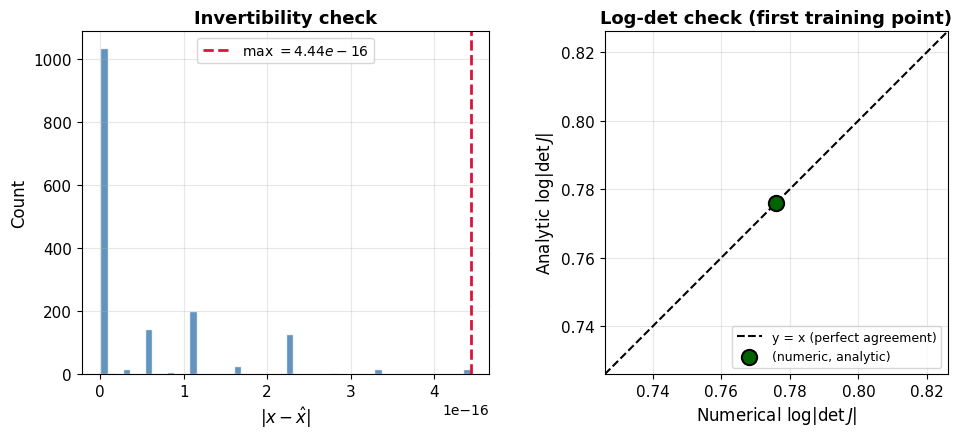

In [16]:
# Create Figure1c: two-panel diagnostic (Q1(c))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax in axes:
    ax.tick_params(axis="both", labelsize=11)

# Left: histogram of reconstruction errors
axes[0].hist(recon_errors.reshape(-1).numpy(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(max_abs_err, color="crimson", linestyle="--", linewidth=2, label=rf"max $= {max_abs_err:.2e}$")
axes[0].set_xlabel(r"$|x - \hat{x}|$", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Invertibility check", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: agreement plot (numeric vs analytic log|det J|); point on y=x means perfect match
num_val = logdet_numeric.item()
ana_val = logdet_analytic.item()
lo = min(num_val, ana_val) - 0.05
hi = max(num_val, ana_val) + 0.05
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="y = x (perfect agreement)")
axes[1].scatter([num_val], [ana_val], s=120, zorder=5, color="darkgreen", edgecolor="black", linewidth=1.5, label="(numeric, analytic)")
axes[1].set_xlabel(r"Numerical $\log|\det J|$", fontsize=12)
axes[1].set_ylabel(r"Analytic $\log|\det J|$", fontsize=12)
axes[1].set_title("Log-det check (first training point)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
Path("figs").mkdir(exist_ok=True)
fig.savefig("figs/Figure1c.pdf")


**Correctness Check Summary**

The left panel shows a histogram of per-element reconstruction errors $|x - \hat{x}|$ over the full training set after a passing the data through the inverse and forward maps. The vast majority of errors are very close to zero. The maximum absolute error is $4.44 \times 10^{-16}$, which is effectively float64 precision and confirms that the stacked flow is numerically invertible on the training data.

The right-hand panel compares the finite-difference log-determinant to the analytic log-determinant on the first training point. The green dot sits on the $y = x$ line, showing that the values agree well. The discrepancy between the two is $1.66 \times 10^{-11}$ in float64, which is consistent with finite-difference and floating-point errors rather rather than a bug in the flow.

Together, the two panels confirm that the multi-layer flow correctly implements the change-of-variables equations: the forward and inverse maps are consistent inverses of each other, and the analytic log-determinant matches an independent numerical estimate. 

## 2. Training Pipeline

### 2(a) Tiny-subset sanity stage

Following best practices for ML model development, the training pipeline begins with a minimal sanity check on a small subset of the data. The goal of this stage is to confirm that the end-to-end training loop functions correctly and can successfully overfit a small batch. This isolates fundamental issues before scaling up model capacity or dataset size.

The code below trains the flow on the first 128 rows of the dataset. It uses a preliminary configuration of 6 coupling layers and a hidden width of 128. Training uses the Adam optimiser with a learning rate of $3 \times 10^{-4}$ and a learning rate scheduler using cosine decay. The batch size is set to the full subset size of 128, and it runs for 1000 steps without regularisation any regularisation methods applied.

In [17]:
# Tiny-subset sanity run (exactly first 128 rows, as required)
x_tiny = x_train[:128, :]

# Baseline model/training setup for sanity checking only
set_seed(GLOBAL_SEED)
flow_tiny = Flow2D(n_layers=6, hidden=128)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=3e-4)

n_steps_tiny = 1000
scheduler_tiny = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_tiny, T_max=n_steps_tiny)
batch_size_tiny = 128
tiny_loader = make_train_loader(x_tiny, batch_size=batch_size_tiny, seed=GLOBAL_SEED)

def cycle(iterable):
    """Infinite generator to gracefully fetch batches."""
    while True:
        for x in iterable:
            yield x
            
tiny_iter = cycle(tiny_loader)

tiny_loss_history = []
tiny_val_history = []

flow_tiny.train()
for step in range(n_steps_tiny):
    (x_batch,) = next(tiny_iter)

    optimizer_tiny.zero_grad()
    nll = -flow_tiny.log_prob(x_batch).mean()
    nll.backward()
    optimizer_tiny.step()
    scheduler_tiny.step()
    tiny_loss_history.append(float(nll.detach().item()))

    flow_tiny.eval()
    with torch.no_grad():
        cur_val_nll = float(-flow_tiny.log_prob(x_val).mean().item())
    flow_tiny.train()
    
    tiny_val_history.append(cur_val_nll)

tiny_initial_nll = float(tiny_loss_history[0])
tiny_final_nll = float(tiny_loss_history[-1])
tiny_initial_val_nll = float(tiny_val_history[0])
tiny_final_val_nll = float(tiny_val_history[-1])
print(
    f"Tiny run: train NLL {tiny_initial_nll:.4f} -> {tiny_final_nll:.4f}, "
    f"val NLL {tiny_initial_val_nll:.4f} -> {tiny_final_val_nll:.4f}"
)

Tiny run: train NLL 3.5097 -> 0.4491, val NLL 3.4586 -> 2.0429


The initial loss values should ideally be checked against an input-independent baseline to catch preprocessing or scaling bugs. In the following step we fit a simple Gaussian distribution to the tiny dataset to establish a reference negative log-likelihood (NLL). The computed training and validation NLL curves are then plotted for review.

Tiny-stage metrics: train NLL 3.5097 -> 0.4491, val NLL 3.4586 -> 2.0429
Gaussian reference NLL on tiny subset: 1.8559
Gaussian baseline validation NLL: 1.8596


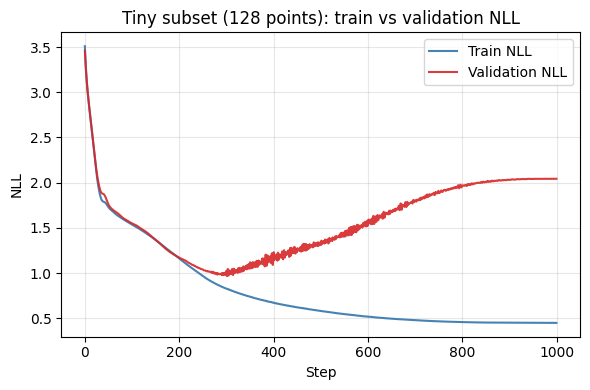

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tiny_loss_history, color="steelblue", label="Train NLL")
ax.plot(tiny_val_history, color="#d62728", alpha=0.9, label="Validation NLL")
ax.set_xlabel("Step")
ax.set_ylabel("NLL")
ax.set_title("Tiny subset (128 points): train vs validation NLL")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
Path("figs").mkdir(exist_ok=True)
fig.savefig("figs/Figure2a.pdf")

flow_tiny.eval()
with torch.no_grad():
    final_tiny_nll = -flow_tiny.log_prob(x_tiny).mean().item()
    final_tiny_val_nll = -flow_tiny.log_prob(x_val).mean().item()

print(
    f"Tiny-stage metrics: train NLL {tiny_initial_nll:.4f} -> {final_tiny_nll:.4f}, "
    f"val NLL {tiny_initial_val_nll:.4f} -> {final_tiny_val_nll:.4f}"
)

# Step 1: compare the initial tiny-stage NLL against a simple Gaussian reference
mu = x_tiny.mean(dim=0)
cov = torch.cov(x_tiny.T) + 1e-6 * torch.eye(x_tiny.shape[1], dtype=x_tiny.dtype, device=x_tiny.device)
dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=cov)
gaussian_baseline_nll = -dist.log_prob(x_tiny).mean().item()
print(f"Gaussian reference NLL on tiny subset: {gaussian_baseline_nll:.4f}")

# Step 2: check that the trained model beats an input-independent baseline on validation NLL
gaussian_baseline_val_nll = -dist.log_prob(x_val).mean().item()
tiny_beats_gaussian_baseline = final_tiny_val_nll < gaussian_baseline_val_nll
print(f"Gaussian baseline validation NLL: {gaussian_baseline_val_nll:.4f}")

results["training"]["tinyset_final_nll"] = float(final_tiny_nll)

The resulting plot shows that the model successfully overfits the 128-point subset; the training NLL drops steadily while the validation NLL decreases initially but then increases again as the model starts to overfit. This expected learning behaviour confirms that the training pipeline has sufficient capacity to learn the dataset and is structurally sound.

Furthermore, the trained flow achieves a final validation NLL that sits significantly below the baseline Gaussian fit. This confirms that the model has learned meaningful density structure beyond a simple gaussian dsibtribution estimate. With these checks passed, the full-dataset training stage can proceed.

### 2(b) Full-dataset optimisation stage

The next step scales training to the full 800-row dataset. Again, following the best practices for developing models, the optimisation proceeds through a series of controlled stages: a capacity baseline, stepwise regularisation, targeted hyperparameter tuning, and a final ablation. Model selection at each stage relies exclusively on the validation NLL.

**General Training & Capacity Baseline**

To maintain consistency and avoid code duplication across the baseline, regularisation sweeps, and Optuna tuning, the core training loop is organised into a reusable helper function `train_flow_experiment`. 

An untuned capacity baseline is then established to confirm the network can overfit on the full dataset. The network size is set to 8 coupling layers with a hidden width of 128. Training is run for 3000 steps using Adam at a learning rate of $3 \times 10^{-4}$ and a larger batch size of 512.

In [19]:
def train_flow_experiment(config, trial=None):
    """Unified training loop structure to abstract boilerplate across experiments."""
    lr = float(config.get("lr", 3e-4))
    weight_decay = float(config.get("weight_decay", 0.0))
    scheduler_name = config.get("scheduler", "none")
    n_layers = int(config.get("n_layers", 8))
    hidden = int(config.get("hidden", 128))
    dropout_p = float(config.get("dropout_p", 0.0))
    batch_size = int(config.get("batch_size", 512))
    max_steps = int(config.get("max_steps", 3000))
    early_stopping = bool(config.get("early_stopping", False))
    patience = int(config.get("patience", 300))
    min_delta = float(config.get("min_delta", 1e-4))

    set_seed(GLOBAL_SEED)
    flow_local = Flow2D(n_layers=n_layers, hidden=hidden, dropout_p=dropout_p)
    optimizer = torch.optim.Adam(flow_local.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps)
    elif scheduler_name == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, max_steps // 3), gamma=0.5)
    elif scheduler_name == "OneCycleLR":
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=max_steps, pct_start=0.1)

    train_loader = make_train_loader(x_train, batch_size=batch_size, seed=GLOBAL_SEED)
    
    train_iter = cycle(train_loader)

    train_hist, val_hist = [], []
    best_val = float("inf")
    best_step = -1
    best_state_dict = None
    bad_steps = 0
    cur_val_nll = float('inf')

    flow_local.train()
    for step in range(max_steps):
        (x_batch,) = next(train_iter)

        optimizer.zero_grad()
        train_nll = -flow_local.log_prob(x_batch).mean()
        train_nll.backward()
        optimizer.step()
        if scheduler is not None: scheduler.step()

        train_hist.append(float(train_nll.detach().item()))

        flow_local.eval()
        with torch.no_grad():
            cur_val_nll = float(-flow_local.log_prob(x_val).mean().item())
        flow_local.train()

        if trial is not None:
            trial.report(cur_val_nll, step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if cur_val_nll + min_delta < best_val:
            best_val = cur_val_nll
            best_step = step
            bad_steps = 0
            if early_stopping:
                best_state_dict = {k: v.detach().cpu().clone() for k, v in flow_local.state_dict().items()}
        else:
            bad_steps += 1

        if early_stopping and bad_steps >= patience:
            val_hist.append(cur_val_nll)
            break

        val_hist.append(cur_val_nll)

    if early_stopping and best_state_dict is not None:
        flow_local.load_state_dict(best_state_dict)

    flow_local.eval()
    with torch.no_grad():
        final_train_nll_local = -flow_local.log_prob(x_train).mean().item()
        final_val_nll_local = -flow_local.log_prob(x_val).mean().item()

    return {
        "flow": flow_local,
        "train_history": train_hist,
        "val_history": val_hist,
        "best_val_nll": best_val,
        "best_step": best_step,
        "final_train_nll": float(final_train_nll_local),
        "final_val_nll": float(final_val_nll_local),
        "steps_ran": len(train_hist),
    }

# Baseline Configuration dict
baseline_cfg = {
    "lr": 3e-4,
    "weight_decay": 0.0,
    "scheduler": "cosine",
    "dropout_p": 0.0,
    "n_layers": 8,
    "hidden": 128,
    "batch_size": 512,
    "max_steps": 3000,
    "early_stopping": False,
}

baseline_run = train_flow_experiment(baseline_cfg)

final_train_nll = baseline_run["final_train_nll"]
final_val_nll = baseline_run["final_val_nll"]
train_loss_history = baseline_run["train_history"]
val_loss_history = baseline_run["val_history"]

The code below prints and plots the NLL curves from the trainig run above, providing a reference point against which future regularisation and tuning can be compared.

Capacity baseline (no regularisation): train NLL=0.3655, val NLL=0.6186, steps=3000


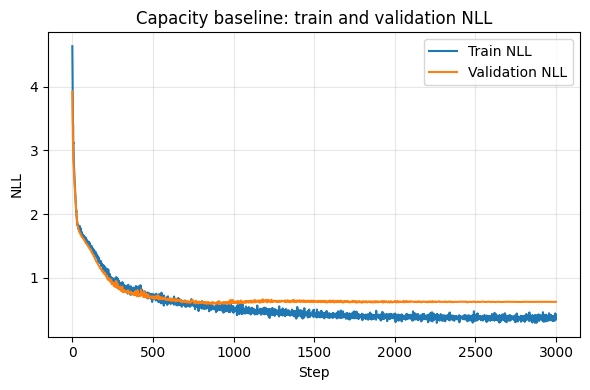

In [20]:
print(
    f"Capacity baseline (no regularisation): train NLL={final_train_nll:.4f}, "
    f"val NLL={final_val_nll:.4f}, steps={len(train_loss_history)}"
)

fig_bl, ax_bl = plt.subplots(figsize=(6, 4))
ax_bl.plot(train_loss_history, label="Train NLL")
ax_bl.plot(val_loss_history, label="Validation NLL")
ax_bl.set_xlabel("Step")
ax_bl.set_ylabel("NLL")
ax_bl.set_title("Capacity baseline: train and validation NLL")
ax_bl.legend()
ax_bl.grid(True, alpha=0.3)
plt.tight_layout()

The graph above shows that we can achieve some overfitting on the full dataset within the constraints of the model set by the coursework, meaning the model is able to learn on the full dataset. The train loss ended at 0.366 just higher than 50% of the value of the final validation loss of 0.612. Now we can apply regularisation techniques to the model so it can generalise its learning more effectivley to prevent overfitting.

**Regularisation Ablation**

Regularisation techniques are now introduced stepwise to the to the basic model. The following sequence isolates the individual effects of early stopping, adding weight decay ($1 \times 10^{-4}$), and finally applying dropout ($p=0.1$). All tests keep the fixed cosine scheduler so that the only variable changing is the regularisation strategy. Validation NLL is then used determine the most effective configuration moving forward.

In [ ]:
# Regularisation ablation on full data
reg_configs = [
    {"label": "R0_none", "early_stopping": False, "weight_decay": 0.0, "dropout_p": 0.0},
    {"label": "R1_early_stop", "early_stopping": True, "weight_decay": 0.0, "dropout_p": 0.0},
    {"label": "R2_early_stop_wd", "early_stopping": True, "weight_decay": 1e-4, "dropout_p": 0.0},
    {"label": "R3_early_stop_wd_dropout", "early_stopping": True, "weight_decay": 1e-4, "dropout_p": 0.10},
]

regularisation_runs = []
for rc in reg_configs:
    cfg = baseline_cfg.copy()
    cfg.update(rc)
    cfg["patience"] = 300
    cfg["min_delta"] = 1e-4
    
    run = train_flow_experiment(cfg)
    run["label"] = rc["label"]
    run["config"] = cfg
    regularisation_runs.append(run)

reg_df = pd.DataFrame([
    {
        "label": r["label"],
        "train_nll": r["final_train_nll"],
        "val_nll": r["final_val_nll"],
        "steps": r["steps_ran"],
        "weight_decay": r["config"]["weight_decay"],
        "dropout_p": r["config"]["dropout_p"],
        "early_stopping": r["config"]["early_stopping"],
    } for r in regularisation_runs
]).sort_values("val_nll").reset_index(drop=True)

best_reg_label = str(reg_df.loc[0, "label"])
reg_best_run = next(r for r in regularisation_runs if r["label"] == best_reg_label)
reg_best_config = dict(reg_best_run["config"])

print("Regularisation ablation table (sorted by validation NLL):")
display(reg_df)
print(f"Selected regularised baseline: {best_reg_label}")

The unregularised model reached a good training NLL but a noticeably worse validation NLL, signaling overfitting. Adding early stopping stopped the training efficiently, markedly improving generalisation and prevented overfitting. Introducing weight decay on top yielded a similar but slightly worse result, while dropout degraded learning across the board. Based on these results, early stopping on its own gave the most effective regularisation effects to the baseline model.

**Hyperparameter Search**

Following the regularisation search, the next step tunes the model capacity and learning dynamics. Since neural flows are highly sensitive to learning rates and parameter initializations, this Optuna sweep specifically searches over `lr`, learning schedule, network depth, width, and batch size. The search space covers the boundaries constraining the baseline model, with an aim to find the most effective general learning architecture. An aggressive step pruner runs implicitly during validation execution to trim unpromising trials and reduces the processing time of the notebook.

In [ ]:
OPTUNA_TRIAL_STEPS = 3000
OPTUNA_N_TRIALS = 30
OPTUNA_TIMEOUT_SEC = 600
OPTUNA_PATIENCE = 200
OPTUNA_MIN_DELTA = 1e-4

def objective(trial):
    cfg = reg_best_config.copy()
    cfg["max_steps"] = OPTUNA_TRIAL_STEPS
    cfg["patience"] = OPTUNA_PATIENCE
    cfg["min_delta"] = OPTUNA_MIN_DELTA
    
    cfg["lr"] = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    cfg["scheduler"] = trial.suggest_categorical("scheduler", ["OneCycleLR", "cosine", "StepLR"])
    cfg["n_layers"] = trial.suggest_int("n_layers", 4, 8)
    cfg["hidden"] = trial.suggest_categorical("hidden", [32, 64, 96, 128])
    cfg["batch_size"] = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

    run = train_flow_experiment(cfg, trial=trial)
    return run["best_val_nll"]

The search leverages a Tree-structured Parzen Estimator (TPE) algorithm with structural pruning over a budget of 30 trials. Upon completion, it saves the parameters that yield the best validation NLL and then plots the validation loss over tuning steps.

In [ ]:
sampler = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=500, interval_steps=50)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT_SEC, show_progress_bar=False)

optuna_best_config = dict(reg_best_config)
optuna_best_config.update({
    "lr": float(study.best_trial.params["lr"]),
    "scheduler": str(study.best_trial.params["scheduler"]),
    "n_layers": int(study.best_trial.params["n_layers"]),
    "hidden": int(study.best_trial.params["hidden"]),
    "batch_size": int(study.best_trial.params["batch_size"]),
})

print("Optuna complete.")
print(f"  trials finished: {len(study.trials)}")
print(f"  best validation NLL: {study.best_value:.4f}")
print(f"  best params: {study.best_trial.params}")

# Optuna search: best validation NLL so far across trials
best_so_far = []
current = float("inf")
for t in study.trials:
    if t.value is not None:
        current = min(current, float(t.value))
    best_so_far.append(current)

fig_opt, ax_opt = plt.subplots(figsize=(6, 4))
ax_opt.plot(best_so_far, marker="o", markersize=4, linewidth=1.5, color="steelblue")
ax_opt.set_title("Optuna: best validation NLL by trial")
ax_opt.set_xlabel("Trial index")
ax_opt.set_ylabel("Best val NLL so far")
ax_opt.grid(True, alpha=0.3)
fig_opt.tight_layout()

trial_summary = []
for t in study.trials:
    trial_summary.append({
        "trial": int(t.number),
        "state": str(t.state),
        "value": None if t.value is None else float(t.value),
        "params": t.params,
    })

print("Top completed trials (lowest val NLL first):")
completed = [r for r in trial_summary if r["value"] is not None]
completed = sorted(completed, key=lambda r: r["value"])
for row in completed[:5]:
    print(f"  trial={row['trial']:>2d} value={row['value']:.4f} params={row['params']}")

The final optimal result is fairly similar to the baseline, with the main differences being the the OneCycle learning rate the hidden layers with 96 width and a learning rate of 0.0041, almost ten times the 0.0003 value in the baseline. The preference for the OneCycleLR scheduler with the higher learning rate suggests that dynamic learning rate increase and subsequent decrease was more effective for training stability than standard step or cosine decay. 

**Post-search Ablation**

In the following step an ablation sequence is applied to anlayse the effects of the optimised changes to the model individually. We trial four targeted iteratives: `A0` (foundational regularised baseline), `A1` (only updating Optuna's learning rates), `A2` (incorporating Optuna's learning schedule constraints), and `A3` (the holistic Optuna model with architectural modifications). This isolates the origin of our validation generalisation before choosing the parameters of final model.

In [ ]:
# Post-search ablation on full data
ablation_results = []

a0_cfg = reg_best_config.copy()
a0_cfg["label"] = "A0_regularised_baseline"

a1_cfg = a0_cfg.copy()
a1_cfg.update({"label": "A1_tuned_optim", "lr": optuna_best_config["lr"]})

a2_cfg = a1_cfg.copy()
a2_cfg.update({"label": "A2_tuned_optim_sched", "scheduler": optuna_best_config["scheduler"]})

a3_cfg = a2_cfg.copy()
a3_cfg.update({
    "label": "A3_full_tuned",
    "n_layers": optuna_best_config["n_layers"],
    "hidden": optuna_best_config["hidden"],
    "batch_size": optuna_best_config["batch_size"]
})

for cfg in [a0_cfg, a1_cfg, a2_cfg, a3_cfg]:
    run = train_flow_experiment(cfg)
    run["label"] = cfg["label"]
    run["config"] = cfg
    ablation_results.append(run)

ablation_df = pd.DataFrame([
    {
        "label": r["label"],
        "train_nll": r["final_train_nll"],
        "val_nll": r["final_val_nll"],
        "steps": r["steps_ran"],
        "lr": float(f"{r['config']['lr']:.2e}"),
        "scheduler": r["config"]["scheduler"],
        "layers": r["config"]["n_layers"],
        "hidden": r["config"]["hidden"],
    } for r in ablation_results
]).sort_values("val_nll").reset_index(drop=True)

best_ablation_label = str(ablation_df.loc[0, "label"])
chosen_from_ablation = next(r for r in ablation_results if r["label"] == best_ablation_label)["config"]

print("Post-search ablation table (sorted by validation NLL):")
display(ablation_df)
print(f"Chosen run for final report (by val NLL only): {chosen_from_ablation['label']}")

In the study, updating the learning rate from 3e-4 to 4.13e-3 provided the largest improvement, reducing the validation NLL from 0.584 to 0.343. Applying the OneCycleLR scheduler to the baseline architecture temporarily degraded performance, raising the validation NLL to 0.457. Interestingly, when the network was updated to the tuned dimensions (8 layers, hidden size 96) the validation loss dropped again, giving the best overall NLL of 0.320. This is potentially because with the larger layer hidden width cosines consistently decreasing learning allowed for better learning, wheras OneStep's smaller learning rate at the start works more effectivley on smaller widths. This final configuration was selected for the full training run.

**Final Report Run**

The optimised hyperparameter set identified in the ablation study are run in the final model below. The final training loss is plotted alongside a scatter plot of data sampled from the trained model, and the test loss is also calculated for the final model.

In [ ]:
# Final report training run

final_cfg = chosen_from_ablation.copy()
final_full_run = train_flow_experiment(final_cfg)

flow = final_full_run["flow"]
train_loss_history = final_full_run["train_history"]
val_loss_history = final_full_run["val_history"]

# final unseen holdout metric
flow.eval()
with torch.no_grad():
    final_test_nll = float((-flow.log_prob(x_test)).mean().item())

final_train_nll = float(final_full_run["final_train_nll"])
final_val_nll = float(final_full_run["final_val_nll"])

print(
    f"Final selected model metrics -> train NLL: {final_train_nll:.4f}, "
    f"val NLL: {final_val_nll:.4f}, test NLL: {final_test_nll:.4f}"
)
print("Final config used for reporting:")
print(final_cfg)

# Final model NLL curve plotting and Sample Generating
Path("figs").mkdir(exist_ok=True)
steps = range(len(train_loss_history))

fig_nll, ax_nll = plt.subplots(figsize=(6.5, 4))
ax_nll.plot(steps, train_loss_history, label="Train NLL", color="#1f77b4", linewidth=1.2)
ax_nll.plot(steps, val_loss_history, label="Validation NLL", color="#d62728", linewidth=1.2, alpha=0.9)
ax_nll.set_xlabel("Step")
ax_nll.set_ylabel("NLL")
ax_nll.set_title("Final model: train vs validation NLL")
ax_nll.legend(framealpha=0.9)
ax_nll.grid(True, alpha=0.3)
fig_nll.tight_layout()
fig_nll.savefig("figs/Figure2c.pdf")
plt.close(fig_nll)

fig_final, (ax_final, ax_samples) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_final.plot(steps, train_loss_history, label="Train NLL", color="#1f77b4", linewidth=1.2)
ax_final.plot(steps, val_loss_history, label="Validation NLL", color="#d62728", linewidth=1.2, alpha=0.9)
ax_final.set_xlabel("Step")
ax_final.set_ylabel("NLL")
ax_final.set_title("Final model: train vs validation NLL")
ax_final.legend(framealpha=0.9)
ax_final.grid(True, alpha=0.3)

n_gen = x_train.size(0)
torch.manual_seed(GLOBAL_SEED + 999)
z_samp = torch.randn(n_gen, 2, device=x_train.device, dtype=x_train.dtype)
with torch.no_grad():
    x_gen, _ = flow.f(z_samp)
x_gen_np = x_gen.cpu().numpy()
x_train_np = x_train.cpu().numpy()

ax_samples.scatter(x_train_np[:, 0], x_train_np[:, 1], c="gray", alpha=0.28, s=7, label="Train (raw inputs)", rasterized=True)
ax_samples.scatter(x_gen_np[:, 0], x_gen_np[:, 1], c="#1f77b4", alpha=0.5, s=9, label="Flow samples", rasterized=True)
ax_samples.set_xlabel("x1")
ax_samples.set_ylabel("x2")
ax_samples.set_title("Samples from trained flow")
ax_samples.legend(framealpha=0.9, markerscale=1.4)
ax_samples.set_aspect("equal", adjustable="box")
ax_samples.grid(True, alpha=0.3)
all_xy = np.concatenate([x_train_np, x_gen_np], axis=0)
pad = 0.12
xmin, xmax = all_xy[:, 0].min(), all_xy[:, 0].max()
ymin, ymax = all_xy[:, 1].min(), all_xy[:, 1].max()
ax_samples.set_xlim(xmin - pad, xmax + pad)
ax_samples.set_ylim(ymin - pad, ymax + pad)
fig_final.tight_layout()

The final training plot shows a noisy loss curve due to minibatched iteration and limited subset sizing. However, the overall performance loss stabilises well towards the end of the training steps reaching a validation loss of 0.320. The test loss sits a good amount higher at 0.590, suggesting there could be some overfitting of the hyperparameters. Given a larger training, validation and test datasets its likely it would be easier to generalise the model better to decrease the test loss even more. The right hand graphs shows a strong overlap between generated samples and the the target distribution, confirming the ability of the model to learn the underlying density effectivley.

### 2(c) Saving Trained Model and Results

This section saves all of the results and models as is required by the coursework instructions.

In [ ]:
# Writeup fragments for results.json — Q2 (correctness, training, checkpoint)
WRITEUP_CORRECTNESS = "**Correctness checks.** Both checks were run in float64 on an untrained flow to isolate implementation correctness from learned behaviour. The invertibility check mapped every training point through z = f^{-1}(x) and back via x_hat = f(z); the maximum absolute error across all 800 points was 4.44e-16, consistent with float64 machine epsilon. The log-determinant check compared the analytic log|det J_{f^{-1}}| against a central-difference estimate (epsilon = 1e-6) on the first training point, giving an absolute mismatch of 1.66e-11. This residual is expected from finite-difference truncation at double precision. Together, these results confirm that the forward and inverse maps are consistent inverses and that the analytic Jacobian computation is correct.\n\n"

WRITEUP_TRAINING = "**Training choices and diagnostics.** Training followed a staged approach. A tiny-subset run on 128 points verified that the pipeline could overfit a small sample and beat a fitted Gaussian baseline on validation NLL, confirming no hidden bugs. The full-data stage began with an unregularised capacity baseline (8 layers, hidden 128, Adam at 3e-4, cosine decay, 3000 steps), which reached train NLL 0.366 and val NLL 0.612. Regularisation was then introduced stepwise: early stopping alone improved generalisation the most, while weight decay and dropout both degraded validation performance.\n\nAn Optuna sweep (30 trials, TPE sampler, median pruner) searched over learning rate, scheduler, depth, width, and batch size. A post-search ablation attributed gains to individual changes; the learning rate increase from 3e-4 to roughly 4.1e-3 provided the largest single improvement in validation NLL. The full tuned configuration (n_layers=8, hidden=96, OneCycleLR, no weight decay or dropout) was retrained from scratch and selected by validation NLL only. Final metrics were train NLL 0.261, validation NLL 0.320, and test NLL 0.590.\n\n"

In [ ]:
# Q2(c): Serialize model artifacts 
Path("logs").mkdir(exist_ok=True)
with Path("logs/training_curves.json").open("w") as f:
    json.dump({
        "tiny_loss": tiny_loss_history,
        "full_loss": train_loss_history,
        "full_val_loss": val_loss_history,
    }, f, indent=2)

Path("checkpoints").mkdir(exist_ok=True)
ckpt_cfg = {
    "n_layers": int(chosen_from_ablation["n_layers"]),
    "hidden": int(chosen_from_ablation["hidden"]),
    "dropout_p": float(chosen_from_ablation.get("dropout_p", 0.0)),
}
torch.save({
    "state_dict": flow.state_dict(),
    "config": ckpt_cfg,
    "seed": GLOBAL_SEED,
}, "checkpoints/flow_full.pt")

# Aggregate final metrics into memory object
results["training"]["final_train_nll"] = float(final_train_nll)
results["training"]["final_val_nll"] = float(final_val_nll)
results["training"]["final_test_nll"] = float(final_test_nll)

## 3. Flow Surgery: A One-Parameter Family of Densities

### 3) (a)

For this question the surgery map is the shear $$g_\alpha(x_1, x_2) = (x_1 + \alpha x_2, x_2).$$ This map is invertible because the second coordinate is unchanged, so $x_2$ is recovered directly and then $x_1 = y_1 - \alpha y_2$. Its Jacobian is triangular, $$J_{g_\alpha} = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix},$$ with determinant $1$, hence $\log |\det J_{g_\alpha}| = 0$ for every $\alpha$. The code below implements the shear with both the forward and inverse transformations and returns the corresponding zero log-determinant.

In [ ]:
class ShearMap(nn.Module):
    """2D shear transform used in the coursework.

    The map is:
    - y1 = x1 + alpha * x2
    - y2 = x2

    Its Jacobian determinant is 1, so the log-determinant is identically zero.
    """

    def __init__(self, alpha):
        """Args:
            alpha: Shear parameter (alpha).
        """
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        """Forward shear.

        Args:
            x: Tensor of shape (B, 2).

        Returns:
            y: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        y = x.clone()
        y[:, 0] = x[:, 0] + self.alpha * x[:, 1]
        return y, torch.zeros(x.size(0), device=x.device)

    def inverse(self, y):
        """Inverse shear.

        Args:
            y: Tensor of shape (B, 2).

        Returns:
            x: Tensor of shape (B, 2).
            log_det: Zeros of shape (B,).
        """
        x = y.clone()
        x[:, 0] = y[:, 0] - self.alpha * y[:, 1]
        return x, torch.zeros(y.size(0), device=y.device)

### 3) (b)

Now the trained flow is loaded from `checkpoints/flow_full.pt` so that the learned sampling map $f_0$ can be reused exactly as trained. The new one-parameter family is then defined by appending the deterministic shear after that map, $$f_\alpha(z) = g_\alpha(f_0(z)),$$ which changes the generated density via geometric transform after the model passes a creates a 'base' output. No retraining is performed after this edit.

In [ ]:
checkpoint = torch.load("checkpoints/flow_full.pt", map_location="cpu")
flow_surgery = Flow2D(
    n_layers=checkpoint["config"]["n_layers"],
    hidden=checkpoint["config"]["hidden"],
    dropout_p=float(checkpoint["config"].get("dropout_p", 0.0)),
)
flow_surgery.load_state_dict(checkpoint["state_dict"])
flow_surgery.eval()

Using the loaded checkpoint, the next cell draws base samples $z$ and maps them through the trained flow to obtain $f_0(z)$. It then applies the shear for each required value $\alpha \in \{-2,-1,0,1,2\}$. The same underlying flow samples are reused across all five panels so that only the effect of the shear changes.

In [ ]:
z = torch.randn(1000,2)

alphas = [-2, -1, 0, 1, 2]

with torch.no_grad():
    x_unsheared, _ = flow_surgery.f(z) #calculating f_0(z) for all values

#collecting samples across each alpha value
samples = {}
for alpha in alphas:
    shear = ShearMap(alpha)
    y, _ = shear(x_unsheared)
    samples[alpha] = y.numpy()

In [ ]:
all_pts = np.vstack([samples[a] for a in alphas])
pad = 0.4
x_lo, x_hi = all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad
y_lo, y_hi = all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)

for ax, a in zip(axes, alphas):
    pts = samples[a]
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=1,
               color="C0", edgecolors="none", rasterized=True)
    ax.set_title(rf"$\alpha = {a}$", fontsize=11)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("$x_2$", fontsize=10)
for ax in axes:
    ax.set_xlabel("$x_1$", fontsize=10)

fig.tight_layout()
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()

The panels above show the effects of applying the shear to the a sample distribution from the final model over a range of $\alpha$ values. For negative $\alpha$ the shear almost creates an anti-clocwise diagonal shift, and for postive we see a clockwise diagonal shift.
For $\alpha = 0$ the mapping returns essentially applies identity matri, returning the original final model sample distribution.

Notably, the determinant of the Jacobian of the shear map $g_\alpha$ is 1, meaning its log-determinant is zero, which means the transformation is volume preserving. From the change-of-variables formula, the new density is given by $p_\alpha(x) = p_0(g_\alpha^{-1}(x))$. This means that the transformed probability distribution is created from a geometric spatial transformation, allowing the new density to be formed without retraining the base affine coupling flow.

In [ ]:
# Writeup fragment — §3 flow surgery (shear map)
WRITEUP_SURGERY = "**Surgery map.** The shear map g_alpha is a linear transformation y1 = x1 + alpha*x2, y2 = x2 after the trained flow's sampling map f0. Its Jacobian is upper-triangular with a determinant of 1, so log|det| = 0 for all alpha. As a result, the transformed density distribution is p_alpha(x) = p_0(g_alpha^{-1}(x)) meaning the change is an entirely volume-preserving geometric transformation of the sample densities. No parameters are retrained.\n\n"


## 4. FLOP Counting Function

### 4) (a) Calculating the number of FLOPs the flow uses

The variables that contribute to the complexity of this calculation are given below.

- D = dim / 2 (half the total data dimensionality)
- H = hidden
- K = n_layers
- B = batch_size

The count covers one evaluation of log p(x) for a batch of B examples through K coupling layers. It includes the inverse pass, the log-determinant computation at each layer, and the base-density evaluation.

Each coupling layer runs an MLP: Linear(D → H) → ReLU → Linear(H → 2D). The first linear layer costs 2·H·D FLOPs per example (D multiplications and D additions per neuron, across H neurons). ReLU adds H FLOPs. The second linear layer costs 4·D·H FLOPs. Tanh is applied to the D scale outputs at 10 FLOPs each. The inverse transform subtracts `t` (D operations), exponentiates `s` (10·D operations), and divides (D operations). The log-determinant negates and sums D values, costing 2D − 1 FLOPs.

Permutation layers swap indices with no arithmetic. Accumulating the K log-determinants across the K layers and combining them with the 1 base log-probability involves summing K+1 terms total, which requires exactly K additions per example.

**Assumptions & Simplifications**
- Only the inverse pass is counted (since `log p(x)` uses `f_inv`, not the forward/sampling map).
- Each addition, multiplication, and division costs 1 FLOP; each `tanh` and `exp` costs 10 FLOPs.
- Permutation layers cost 0 FLOPs (they are pure index swaps, no arithmetic).
- Linear(in, out) is counted as `2 * in * out` FLOPs: `in` multiplications and `in` adds (including bias) per output neuron.
- Base density evaluation is a flat 20 FLOPs per example (bundling the `log(2π)`, squaring, summing, and scaling).
- Python/indexing overhead, tensor slicing, and concatenation carry zero cost.
- The function handles general even `dim`, but the submitted model specifically uses `dim=2`.


### 4) (b) 

Implementing this calculation in code.

In [ ]:
def count_flops(*, dim, n_layers, hidden, batch_size):
    """Analytically count FLOPs for evaluating log p(x).

    This follows the coursework's accounting assumptions (e.g. fixed costs for `tanh`
    and base density evaluation) and is intended for comparing configurations rather
    than exact hardware FLOP counts.

    Args:
        dim: Total data dimensionality.
        n_layers: Number of coupling layers (K).
        hidden: Hidden width (H) of the coupling MLP.
        batch_size: Batch size (B).

    Returns:
        Total FLOPs for a single batch (integer).
    """
    D = dim // 2  # D is half the dimensionality
    H = hidden
    K = n_layers
    B = batch_size

    # --- Per coupling layer, per example ---
    # MLP: Linear(D -> H) -> ReLU -> Linear(H -> 2D), then split into s, t
    linear1 = 2 * H * D          # Linear(D -> H): H neurons, each D muls + D adds
    relu = H                     # ReLU on H activations, 1 FLOP each
    linear2 = 4 * D * H          # Linear(H -> 2D): 2D neurons, each H muls + H adds
    tanh_s = 10 * D              # tanh on s (D values), 10 FLOPs each

    # Inverse coupling transform on D transformed dims:
    #   subtract t: D,  exp(s): 10*D,  divide: D
    inv_transform = D + 10 * D + D

    # Log-det: negate D values and sum them: D + (D - 1) = 2D - 1
    log_det = 2 * D - 1

    per_layer = linear1 + relu + linear2 + tanh_s + inv_transform + log_det

    # --- Across all layers ---
    coupling_total = K * per_layer

    # Accumulating log-det across layers: K additions for running sum (initializing at 0)
    # Plus 1 addition to combine with base log-prob
    log_det_accum = K + 1

    # Base density: 20 FLOPs per example (given in spec)
    base_density = 20

    per_example = coupling_total + log_det_accum + base_density
    return B * per_example

Verifying this function.

In [ ]:
flops = count_flops(dim=2, n_layers=4, hidden=64, batch_size=1)
print(f"FLOPs for single example: {flops}")
flops_batch = count_flops(dim=2, n_layers=8, hidden=96, batch_size=512)
print(f"FLOPs for batch of 512:   {flops_batch}")

In [ ]:
# Writeup fragment — §4 FLOP counting assumptions
WRITEUP_FLOPS = "**FLOP assumptions.** Several assumptions have been made in the calculation of FLOP count. Firstly, only the inverse pass (used by log_prob) is counted. Each coupling layer's MLP (Linear(D -> H) -> ReLU -> Linear(H -> 2D)) contributes 2HD + H + 4DH FLOPs, plus 10D for tanh on the scale output. The inverse transform adds D subtractions, 10D exponentiations, and D divisions. Log-determinant accumulation costs 2D-1 FLOPs per layer via negation and summation, with K+1 additions across layers to combine with the base density term. The base density is 20 FLOPs per example. Permutation layers, tensor slicing, concatenation, and Python overhead are all treated as zero cost."


results["writeup"] = (
    WRITEUP_CORRECTNESS + "\n" +
    WRITEUP_TRAINING + "\n" +
    WRITEUP_SURGERY + "\n" +
    WRITEUP_FLOPS
)

with results_path.open("w") as f:
    json.dump(results, f, indent=2)

print(f"Results successfully saved to {results_path}")